Tổng dữ liệu: 30,341 hàng × 27 cột

Train: 25,996 hàng (2022–2024)
Test : 4,345 hàng (2025)

BẢNG SO SÁNH 3 MODEL
            Model  RMSE   MAE     R²
Linear Regression 28.64 21.48 0.6996
    Random Forest  5.23  0.57 0.9900
          XGBoost  8.46  3.30 0.9738

→ Best model: Random Forest


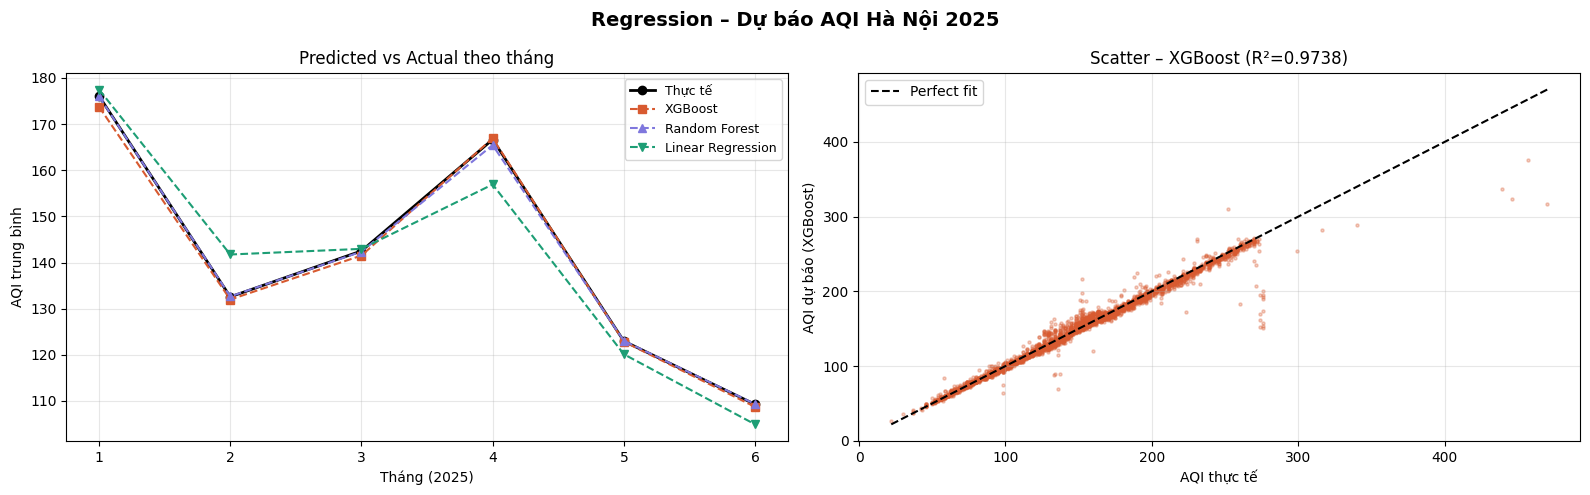

In [1]:
"""
Data: hanoi_aqi_cleaned.csv
Target: aqi (số thực)
Train: 2022–2024 | Test: 2025
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

import xgboost as xgb

try:
    df = pd.read_csv('../clean/hanoi_aqi_cleaned.csv')
except:
    df = pd.read_csv('./hanoi_aqi_cleaned.csv')

df.columns = df.columns.str.strip().str.lower()
df['local_time'] = pd.to_datetime(df['local_time'])
print(f"Tổng dữ liệu: {df.shape[0]:,} hàng × {df.shape[1]} cột")

FEATURES = [
    'co', 'no2', 'o3', 'pm10', 'pm25', 'so2',
    'clouds', 'precipitation', 'pressure',
    'relative_humidity', 'temperature', 'uv_index', 'wind_speed',
    'month', 'hour', 'day_of_week', 'is_weekend', 'is_rush_hour', 'season'
]
TARGET = 'aqi'

train = df[df['year'] < 2025].copy()
test  = df[df['year'] == 2025].copy()

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f"\nTrain: {len(train):,} hàng (2022–2024)")
print(f"Test : {len(test):,} hàng (2025)")

# ══════════════════════════════════════════════════════
# TRAIN 3 MODELS
# ══════════════════════════════════════════════════════

# --- Model 1: Linear Regression (baseline) ---
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# --- Model 2: Random Forest ---
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# --- Model 3: XGBoost ---
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# ══════════════════════════════════════════════════════
# ĐÁNH GIÁ
# ══════════════════════════════════════════════════════
def evaluate(name, y_true, y_pred):
    return {
        'Model': name,
        'RMSE':  round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        'MAE':   round(mean_absolute_error(y_true, y_pred), 2),
        'R²':    round(r2_score(y_true, y_pred), 4)
    }

results = pd.DataFrame([
    evaluate('Linear Regression', y_test, y_pred_lr),
    evaluate('Random Forest',     y_test, y_pred_rf),
    evaluate('XGBoost',           y_test, y_pred_xgb),
])

print("\n" + "="*50)
print("BẢNG SO SÁNH 3 MODEL")
print("="*50)
print(results.to_string(index=False))

# Best model
best_model_name = results.loc[results['RMSE'].idxmin(), 'Model']
best_preds = {'Linear Regression': y_pred_lr,
              'Random Forest': y_pred_rf,
              'XGBoost': y_pred_xgb}[best_model_name]
print(f"\n→ Best model: {best_model_name}")

# ══════════════════════════════════════════════════════
#  VISUALIZE — Predicted vs Actual theo tháng
# ══════════════════════════════════════════════════════
test_plot = test.copy()
test_plot['y_pred_xgb'] = y_pred_xgb
test_plot['y_pred_rf']  = y_pred_rf
test_plot['y_pred_lr']  = y_pred_lr

monthly = test_plot.groupby('month').agg(
    actual   = ('aqi', 'mean'),
    xgb_pred = ('y_pred_xgb', 'mean'),
    rf_pred  = ('y_pred_rf', 'mean'),
    lr_pred  = ('y_pred_lr', 'mean'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Regression – Dự báo AQI Hà Nội 2025', fontsize=14, fontweight='bold')

# Subplot 1: Predicted vs Actual theo tháng
ax1 = axes[0]
months = monthly['month']
ax1.plot(months, monthly['actual'],   'ko-', lw=2, label='Thực tế')
ax1.plot(months, monthly['xgb_pred'], 's--', color='#D85A30', label='XGBoost')
ax1.plot(months, monthly['rf_pred'],  '^--', color='#7F77DD', label='Random Forest')
ax1.plot(months, monthly['lr_pred'],  'v--', color='#1D9E75', label='Linear Regression')
ax1.set_xlabel('Tháng (2025)')
ax1.set_ylabel('AQI trung bình')
ax1.set_title('Predicted vs Actual theo tháng')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)
ax1.set_xticks(months)

# Subplot 2: Scatter Actual vs XGBoost (best model)
ax2 = axes[1]
ax2.scatter(y_test, y_pred_xgb, alpha=0.3, s=5, color='#D85A30')
lims = [min(y_test.min(), y_pred_xgb.min()), max(y_test.max(), y_pred_xgb.max())]
ax2.plot(lims, lims, 'k--', lw=1.5, label='Perfect fit')
ax2.set_xlabel('AQI thực tế')
ax2.set_ylabel('AQI dự báo (XGBoost)')
ax2.set_title(f'Scatter – XGBoost (R²={results.loc[results["Model"]=="XGBoost","R²"].values[0]})')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

